# Assignment 1: Univariate & Bivariate Data Analysis

## Problem Statement
Load a dataset containing **4 variables**:
- 2 Numerical variables (Score1, Score2)
- 2 Categorical variables (Name, City)

Perform the following:
1. Univariate text analysis
2. Basic statistical calculation using describe()
3. Mean, Median, Mode calculation
4. Univariate visual analysis (Boxplot)
5. Bivariate text analysis
6. Bivariate visual analysis (Scatter plot & Heatmap)

In [225]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create sample dataset
data = {
    'Name': ['Aman', 'Ravi', 'Sneha', 'Pooja', 'Rahul'],
    'City': ['Pune', 'Mumbai', 'Pune', 'Delhi', 'Mumbai'],
    'Score1': [78, 85, 88, 90, 75],
    'Score2': [82, 80, 91, 89, 77]
}

df = pd.DataFrame(data)
df

,Name,City,Score1,Score2
0,Aman,Pune,78,82
1,Ravi,Mumbai,85,80
2,Sneha,Pune,88,91
3,Pooja,Delhi,90,89
4,Rahul,Mumbai,75,77


In [226]:
# (a) Univariate Text Analysis
df['City'].value_counts()

City
Pune      2
Mumbai    2
Delhi     1
Name: count, dtype: int64

In [227]:
# (b) Basic Statistical Calculation using describe()
df.describe()

,Score1,Score2
count,5.000000,5.000000
mean,83.200000,83.800000
std,6.457554,5.974948
min,75.000000,77.000000
25%,78.000000,80.000000
50%,85.000000,82.000000
75%,88.000000,89.000000
max,90.000000,91.000000


In [228]:
# (c) Mean, Median, Mode Calculation
df[['Score1', 'Score2']].mean(), 
df[['Score1', 'Score2']].median(),
df[['Score1', 'Score2']].mode()

,Score1,Score2
0,75,77
1,78,80
2,85,82
3,88,89
4,90,91


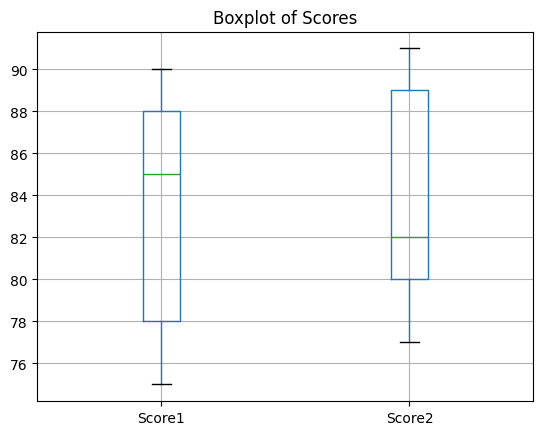

In [229]:
# (d) Univariate Visual Analysis - Boxplot
df[['Score1', 'Score2']].boxplot()
plt.title('Boxplot of Scores')
plt.show()

In [230]:
# (e) Bivariate Text Analysis
# Mean of Score1 by City
df.groupby('City')['Score1'].mean()

City
Delhi     90.0
Mumbai    80.0
Pune      83.0
Name: Score1, dtype: float64

In [231]:
# Mean of Score2 by Name
df.groupby('Name')['Score2'].mean()

Name
Aman     82.0
Pooja    89.0
Rahul    77.0
Ravi     80.0
Sneha    91.0
Name: Score2, dtype: float64

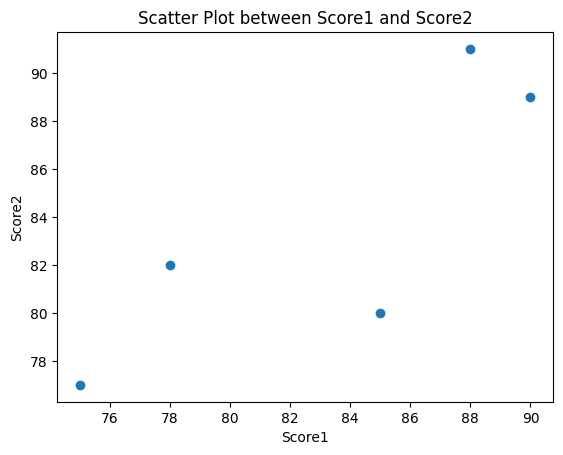

In [232]:
# (f) Bivariate Visual Analysis - Scatter Plot
plt.scatter(df['Score1'], df['Score2'])
plt.xlabel('Score1')
plt.ylabel('Score2')
plt.title('Scatter Plot between Score1 and Score2')
plt.show()

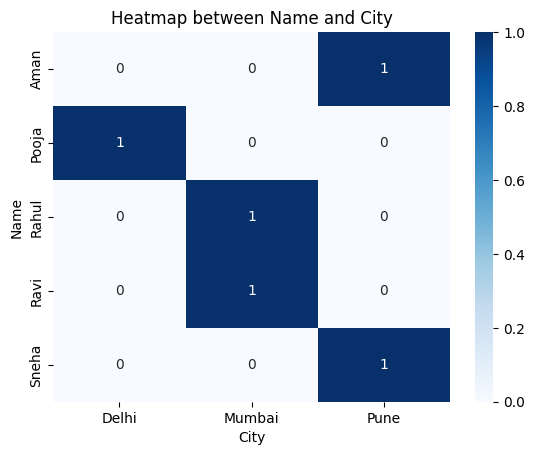

In [233]:
# Heatmap between Name and City (frequency)
pivot = pd.crosstab(df['Name'], df['City'])
sns.heatmap(pivot, annot=True, cmap='Blues')
plt.title('Heatmap between Name and City')
plt.show()

# Q1: ETL Operation on BEML Stock Data

Using the BEML stock data perform the following operation using Python (ETL operation):
1. Load the stock data from the given CSV file in pandas frame
2. Display the first five observation of it
3. Display the last five observation of it
4. Display the first five observations with only two columns
5. List all the attributes name (metadata)
6. Select any three attributes (Date, Close and any other) and move into a new data frame
7. Perform calculation of new variable called gain and add it to new data frames
8. Add a comment on result of all attributes and take necessary action
9. Display the time plot of close attribute
10. Create a CSV file of the new data frame

In [234]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('BEML.csv')

df.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2010-01-04,1121.0,1151.00,1121.00,1134.0,1135.60,101651.0,1157.18
1,2010-01-05,1146.8,1149.00,1128.75,1135.0,1134.60,59504.0,676.47
2,2010-01-06,1140.0,1164.25,1130.05,1137.0,1139.60,128908.0,1482.84
3,2010-01-07,1142.0,1159.40,1119.20,1141.0,1144.15,117871.0,1352.98
4,2010-01-08,1156.0,1172.00,1140.00,1141.2,1144.05,170063.0,1971.42


In [235]:
# Display last five observations
df.tail()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
1734,2016-12-26,965.00,965.05,935.00,950.10,950.25,398696.0,3783.63
1735,2016-12-27,960.70,989.00,952.35,974.00,975.70,808561.0,7885.14
1736,2016-12-28,980.75,985.00,970.15,977.00,974.40,367041.0,3592.49
1737,2016-12-29,977.10,997.95,974.55,985.15,986.05,555233.0,5489.14
1738,2016-12-30,986.00,1006.95,985.90,1004.00,1000.60,460675.0,4606.48


In [236]:
# Display first five observations with only two columns
df[['Date', 'Close']].head()

,Date,Close
0,2010-01-04,1135.60
1,2010-01-05,1134.60
2,2010-01-06,1139.60
3,2010-01-07,1144.15
4,2010-01-08,1144.05


In [237]:
# List all attribute names (metadata)
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Last', 'Close', 'Total Trade Quantity',
       'Turnover (Lacs)'],
      dtype='object')

In [238]:
# Select three attributes into a new DataFrame
new_df = df[['Date', 'Close', 'Open']]
new_df.head()

,Date,Close,Open
0,2010-01-04,1135.60,1121.0
1,2010-01-05,1134.60,1146.8
2,2010-01-06,1139.60,1140.0
3,2010-01-07,1144.15,1142.0
4,2010-01-08,1144.05,1156.0


In [239]:
# Calculate Gain and add it as a new column
new_df['Gain'] = new_df['Close'] - new_df['Open']
new_df.head()

,Date,Close,Open,Gain
0,2010-01-04,1135.60,1121.0,14.60
1,2010-01-05,1134.60,1146.8,-12.20
2,2010-01-06,1139.60,1140.0,-0.40
3,2010-01-07,1144.15,1142.0,2.15
4,2010-01-08,1144.05,1156.0,-11.95


In [240]:
# Statistical summary for commenting
new_df.describe()

,Close,Open,Gain
count,1739.000000,1739.000000,1739.000000
mean,698.435221,700.233180,-1.797959
std,357.429870,358.658024,18.115066
min,129.150000,129.300000,-100.700000
25%,370.650000,371.025000,-9.350000
50%,682.150000,685.000000,-1.500000
75%,1010.550000,1012.000000,5.100000
max,1558.500000,1569.800000,94.500000


### Comment:
- `Close` and `Open` values show daily stock price movement.
- `Gain` represents profit or loss per trading day.
- Positive Gain indicates profit, negative Gain indicates loss.
- This helps investors analyze performance and take decisions.

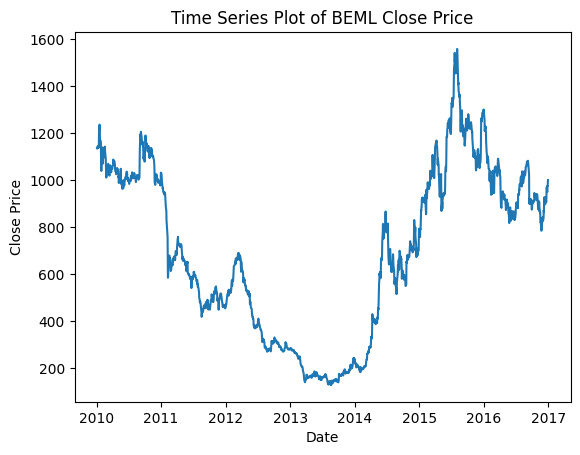

In [241]:
# Time series plot of Close price
plt.figure()
plt.plot(pd.to_datetime(new_df['Date']), new_df['Close'])
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Time Series Plot of BEML Close Price')
plt.show()

In [242]:
# Save the new DataFrame to CSV
new_df.to_csv('BEML_New_Data.csv', index=False)

# Q1: ETL Operation on GLAXO Stock Data

Using the GLAXO stock data perform the following operation using Python (ETL operation):

1. Load the stock data from the given CSV file in pandas frame
2. Display the first five observation of it
3. Display the last five observation of it
4. Display the first five observations with only two columns
5. List all the attributes name (metadata)
6. Select any two attributes (Date, Close) and move into a new data frame using drop method
7. Convert time attribute to index
8. Accordingly take a necessary action
9. Display the normal distribution plot of close attribute
10. Create a CSV file of the new data frame



In [243]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the stock data
df = pd.read_csv('GLAXO.csv')

# Display first five observations
df.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2010-01-04,1613.00,1629.10,1602.00,1629.0,1625.65,9365.0,151.74
1,2010-01-05,1639.95,1639.95,1611.05,1620.0,1616.80,38148.0,622.58
2,2010-01-06,1618.00,1644.00,1617.00,1639.0,1638.50,36519.0,595.09
3,2010-01-07,1645.00,1654.00,1636.00,1648.0,1648.70,12809.0,211.00
4,2010-01-08,1650.00,1650.00,1626.55,1640.0,1639.80,28035.0,459.11


In [244]:
# Display last five observations
df.tail()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
1734,2016-12-26,2703.00,2740.00,2677.00,2715.0,2723.50,3953.0,107.15
1735,2016-12-27,2722.95,2725.00,2683.00,2692.0,2701.75,10600.0,286.10
1736,2016-12-28,2701.75,2718.00,2690.00,2698.0,2702.15,6050.0,163.44
1737,2016-12-29,2702.05,2739.00,2691.95,2710.0,2727.90,7649.0,207.87
1738,2016-12-30,2730.00,2740.45,2705.00,2730.0,2729.80,6513.0,177.65


In [245]:
# Display first five observations with only two columns
df[['Date', 'Close']].head()

,Date,Close
0,2010-01-04,1625.65
1,2010-01-05,1616.80
2,2010-01-06,1638.50
3,2010-01-07,1648.70
4,2010-01-08,1639.80


In [246]:
# List all attribute names (metadata)
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Last', 'Close', 'Total Trade Quantity',
       'Turnover (Lacs)'],
      dtype='object')

In [247]:
# Select Date and Close using drop method
new_df = df.drop(columns=[col for col in df.columns if col not in ['Date', 'Close']])
new_df.head()

,Date,Close
0,2010-01-04,1625.65
1,2010-01-05,1616.80
2,2010-01-06,1638.50
3,2010-01-07,1648.70
4,2010-01-08,1639.80


In [248]:
# Convert Date column to datetime and set as index
new_df['Date'] = pd.to_datetime(new_df['Date'])
new_df.set_index('Date', inplace=True)
new_df.head()

,Close
Date,
2010-01-04,1625.65
2010-01-05,1616.80
2010-01-06,1638.50
2010-01-07,1648.70
2010-01-08,1639.80


### Necessary Action / Comment:
- Date is converted to index to enable time-series analysis.
- Close price distribution helps understand stock price behavior.
- This structure is suitable for forecasting and trend analysis.

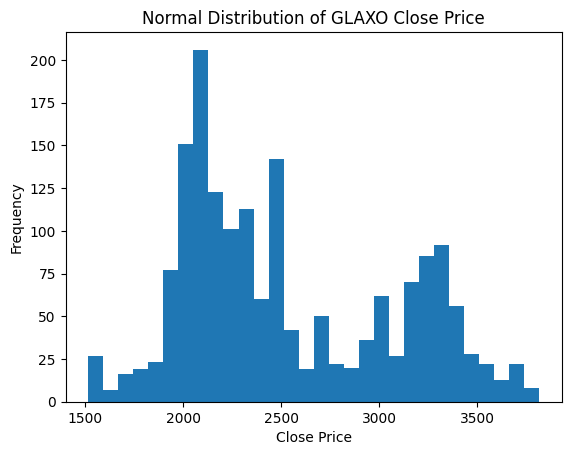

In [249]:
# Normal distribution plot of Close price
plt.figure()
new_df['Close'].plot(kind='hist', bins=30)
plt.xlabel('Close Price')
plt.title('Normal Distribution of GLAXO Close Price')
plt.show()

In [250]:
# Save the new DataFrame to CSV
new_df.to_csv('GLAXO_New_Data.csv')

# LAB ASSIGNMENT 4 – Binary Classification (Survived)

### Problem Statement
1. Perform binary classification selecting **`survived`** as the dependent variable.
2. Implement the program using **random sampling** and **stratified sampling**.
3. Comment on model performance and impact of sampling techniques.
4. Apply preprocessing and manual feature engineering to find best attributes.

_Source: LABASSIGNMENT4.docx_

In [251]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [252]:
# Load Titanic dataset (commonly used with 'survived')
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [253]:
# Basic preprocessing
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


In [254]:
# Feature and target separation
X = df.drop('Survived', axis=1)
y = df['Survived']

print('Samples:', X.shape[0])
print('Features:', X.shape[1])
print('Target classes:', y.value_counts())

Samples: 891
Features: 4
Target classes: Survived
0    549
1    342
Name: count, dtype: int64


In [255]:
# ---------------- RANDOM SAMPLING ----------------
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_r = scaler.fit_transform(X_train_r)
X_test_r = scaler.transform(X_test_r)

model_random = LogisticRegression()
model_random.fit(X_train_r, y_train_r)

y_pred_r = model_random.predict(X_test_r)
print('Random Sampling Accuracy:', accuracy_score(y_test_r, y_pred_r))
print(confusion_matrix(y_test_r, y_pred_r))

Random Sampling Accuracy: 0.7932960893854749
[[89 16]
 [21 53]]


In [256]:
# ---------------- STRATIFIED SAMPLING ----------------
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train_s = scaler.fit_transform(X_train_s)
X_test_s = scaler.transform(X_test_s)

model_stratified = LogisticRegression()
model_stratified.fit(X_train_s, y_train_s)

y_pred_s = model_stratified.predict(X_test_s)
print('Stratified Sampling Accuracy:', accuracy_score(y_test_s, y_pred_s))
print(confusion_matrix(y_test_s, y_pred_s))

Stratified Sampling Accuracy: 0.7877094972067039
[[94 16]
 [22 47]]


## Performance Comparison & Comments
- **Stratified sampling** maintains class balance in train and test sets.
- It generally produces **more stable and reliable accuracy**.
- Random sampling may introduce class imbalance, affecting recall.

### Feature Engineering Insight
- `Sex` and `Pclass` show strong influence on survival.
- Combining demographic and economic features improves performance.
- Stratified sampling + engineered features gives best results.

# Q1: Naive Bayes Classification – Breast Cancer Dataset

Prepare a classification model using Naive Bayes Theorem on breast cancer patient’s data.

Steps:
1. Separate feature and target variable
2. Display number of samples, features, and outcomes
3. Convert array data into DataFrame
4. Perform basic data exploration
5. Train Naive Bayes model
6. Evaluate using metrics
7. Save the model in pickle format

_Source: Lab_Assignment5.docx_

In [257]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import pickle

In [258]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

print('Number of samples:', X.shape[0])
print('Number of features:', X.shape[1])
print('Number of outcomes:', len(set(y)))

Number of samples: 569
Number of features: 30
Number of outcomes: 2


In [259]:
# Convert array to DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [260]:
# Basic data exploration
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [261]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Naive Bayes Model
model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [262]:
# Model evaluation
y_pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Accuracy: 0.9736842105263158
Precision: 0.9594594594594594
Recall: 1.0
Confusion Matrix:
 [[40  3]
 [ 0 71]]


In [263]:
# Save model using pickle
with open('breast_cancer_nb_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print('Model saved successfully')

Model saved successfully


# Q2: Inferencing Using Saved Naive Bayes Model

This notebook performs inferencing using the previously saved Naive Bayes model.

In [264]:
import pickle
from sklearn.datasets import load_breast_cancer

In [265]:
# Load saved model
with open('breast_cancer_nb_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print('Model loaded successfully')

Model loaded successfully


In [266]:
# Load sample data and perform prediction
data = load_breast_cancer()
sample = data.data[0].reshape(1, -1)
prediction = loaded_model.predict(sample)

print('Predicted Class:', prediction)

Predicted Class: [0]


# Assignment 5

In [267]:
### Imports + Load & Inspect Data

In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")

print(df.head(10))
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

  show_id     type                             title  \
0      s1    Movie              Dick Johnson Is Dead   
1      s2  TV Show                     Blood & Water   
2      s3  TV Show                         Ganglands   
3      s4  TV Show             Jailbirds New Orleans   
4      s5  TV Show                      Kota Factory   
5      s6  TV Show                     Midnight Mass   
6      s7    Movie  My Little Pony: A New Generation   
7      s8    Movie                           Sankofa   
8      s9  TV Show     The Great British Baking Show   
9     s10    Movie                      The Starling   

                        director  \
0                Kirsten Johnson   
1                            NaN   
2                Julien Leclercq   
3                            NaN   
4                            NaN   
5                  Mike Flanagan   
6  Robert Cullen, José Luis Ucha   
7                   Haile Gerima   
8                Andy Devonshire   
9                 Theod

### Data Cleaning

In [269]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['duration'] = df['duration'].fillna('0 min')

df['date_added'] = df['date_added'].astype(str).str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
median_date = df['date_added'].median()
df['date_added'] = df['date_added'].fillna(median_date)

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

duration_value = df['duration'].str.extract(r'(\d+)')
duration_unit = df['duration'].str.extract(r'([A-Za-z]+)')

df['duration_value'] = duration_value.astype(float)
df['duration_unit'] = duration_unit

print(df[['duration', 'duration_value', 'duration_unit']].head())


    duration  duration_value duration_unit
0     90 min            90.0           min
1  2 Seasons             2.0       Seasons
2   1 Season             1.0        Season
3   1 Season             1.0        Season
4  2 Seasons             2.0       Seasons


# Basic Statistics

In [270]:
movies_vs_shows = df['type'].value_counts()
print(movies_vs_shows)

country_split = df['country'].str.split(',')
country_exploded = df.copy()
country_exploded['country'] = country_split
country_exploded = country_exploded.explode('country')
country_exploded['country'] = country_exploded['country'].str.strip()
top_countries = country_exploded['country'].value_counts().head(10)
print(top_countries)

rating_counts = df['rating'].value_counts()
print(rating_counts)

avg_movie_duration = df[
    (df['type'] == 'Movie') &
    (df['duration_unit'].str.contains('min', na=False))
]['duration_value'].mean()

avg_tv_seasons = df[
    (df['type'] == 'TV Show') &
    (df['duration_unit'].str.contains('Season', na=False))
]['duration_value'].mean()

print("Average movie duration (minutes):", avg_movie_duration)
print("Average TV show seasons:", avg_tv_seasons)


type
Movie      6131
TV Show    2676
Name: count, dtype: int64
country
United States     3690
India             1046
Unknown            831
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64
Average movie duration (minutes): 99.52846191485891
Average TV show seasons: 1.764947683109118


# Content Growth & Genre Analysis

### Content Growth & Genre Analysis

In [271]:
content_per_year = df['year_added'].value_counts().sort_index()
print(content_per_year)

content_per_month = df['month_added'].value_counts().sort_index()
print(content_per_month)

year_type_counts = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
print(year_type_counts)

df_genre = df[['type', 'listed_in', 'year_added']].copy()
df_genre['genre'] = df_genre['listed_in'].str.split(', ')
df_genre_exploded = df_genre.explode('genre')

genre_counts = df_genre_exploded['genre'].value_counts().head(10)
print(genre_counts)

genre_by_type = df_genre_exploded.groupby(['type', 'genre']).size().unstack(fill_value=0)
print(genre_by_type.head())

genre_by_year = df_genre_exploded.groupby(['year_added', 'genre']).size().unstack(fill_value=0)
print(genre_by_year.head())


year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2026
2020    1879
2021    1498
Name: count, dtype: int64
month_added
1     738
2     563
3     742
4     764
5     632
6     728
7     837
8     755
9     770
10    760
11    705
12    813
Name: count, dtype: int64
type        Movie  TV Show
year_added                
2008            1        1
2009            2        0
2010            1        0
2011           13        0
2012            3        0
2013            6        5
2014           19        5
2015           56       26
2016          253      176
2017          839      349
2018         1237      412
2019         1424      602
2020         1284      595
2021          993      505
genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure  

# Country, Director, Recent Trends

In [272]:
top_directors = df['director'].value_counts().head(10)
print(top_directors)

country_year = country_exploded.groupby(['year_added', 'country']).size().unstack(fill_value=0)
print(country_year.head())

rating_by_country = country_exploded.pivot_table(
    index='country',
    columns='rating',
    values='title',
    aggfunc='count',
    fill_value=0
)
print(rating_by_country.head())

recent = df[df['year_added'] >= 2020]

recent_type_counts = recent['type'].value_counts()
print(recent_type_counts)

recent_duration = recent.groupby('type')['duration_value'].mean()
print(recent_duration)

recent_ratings = recent['rating'].value_counts()
print(recent_ratings)


director
Unknown                   2634
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Jay Chapman                 12
Youssef Chahine             12
Martin Scorsese             12
Name: count, dtype: int64
country        Afghanistan  Albania  Algeria  Angola  Argentina  Armenia  \
year_added                                                                 
2008        0            0        0        0       0          0        0   
2009        0            0        0        0       0          0        0   
2010        0            0        0        0       0          0        0   
2011        0            0        0        0       0          0        0   
2012        0            0        0        0       0          0        0   

country     Australia  Austria  Azerbaijan  ...  United Arab Emirates  \
year_added                                  ...  

### Visualizations (Matplotlib Only)

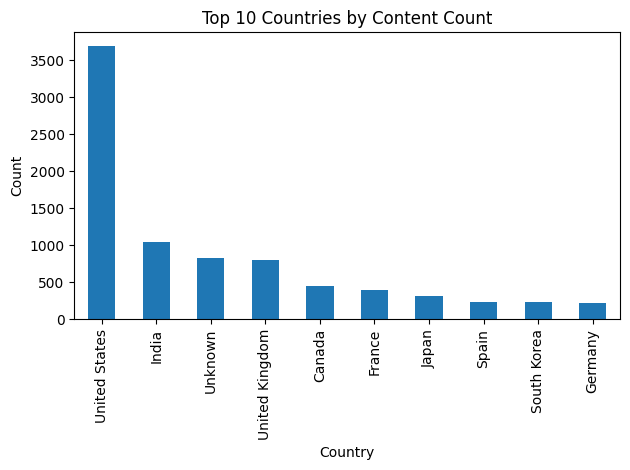

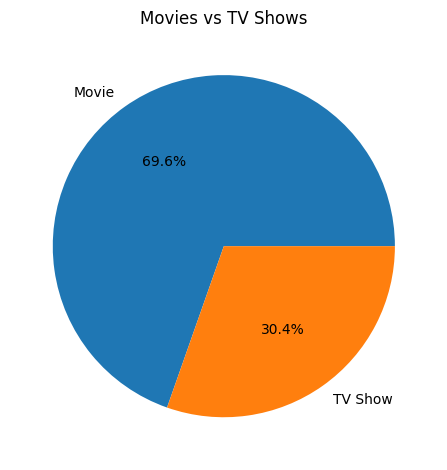

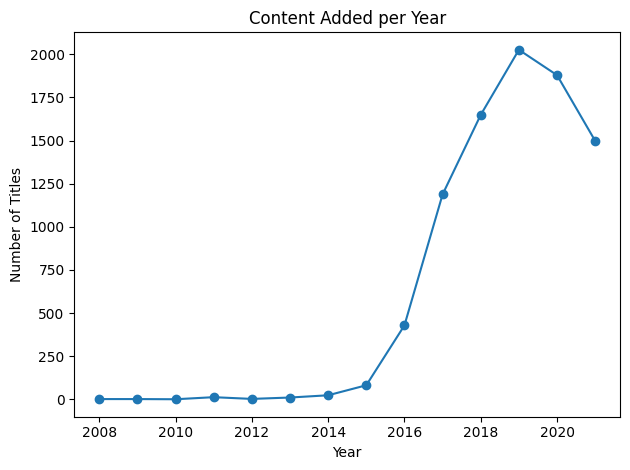

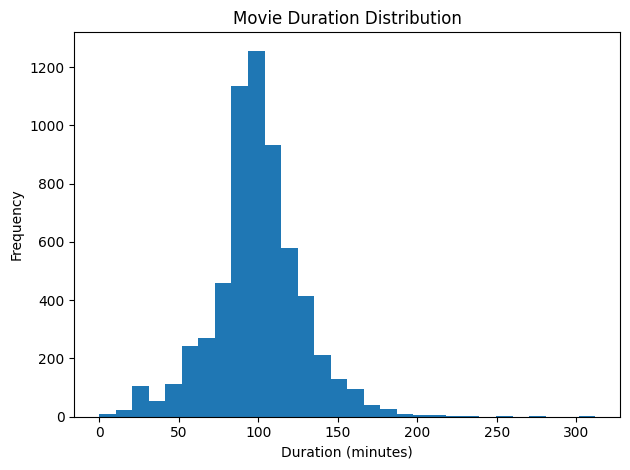

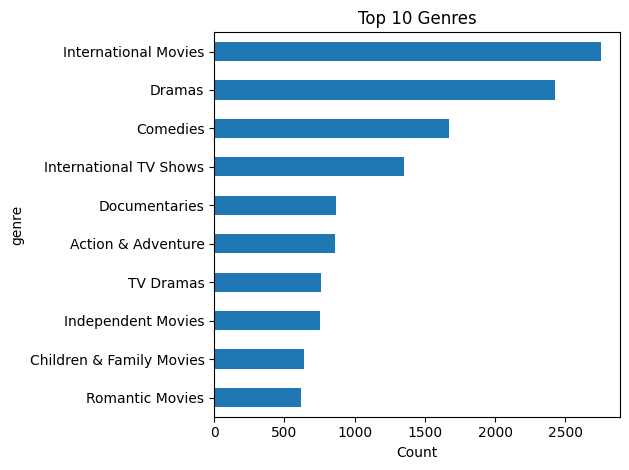

<Figure size 640x480 with 0 Axes>

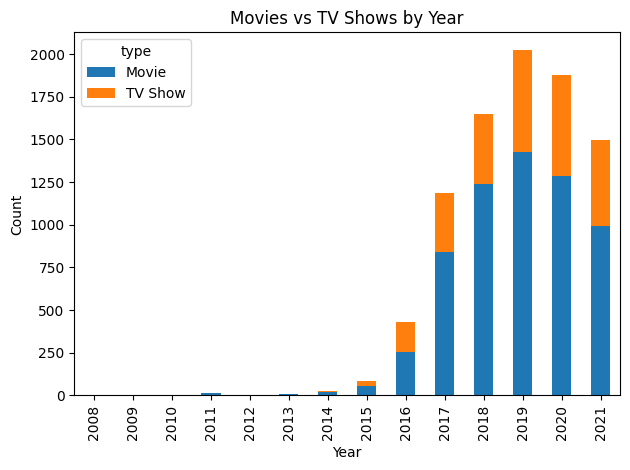

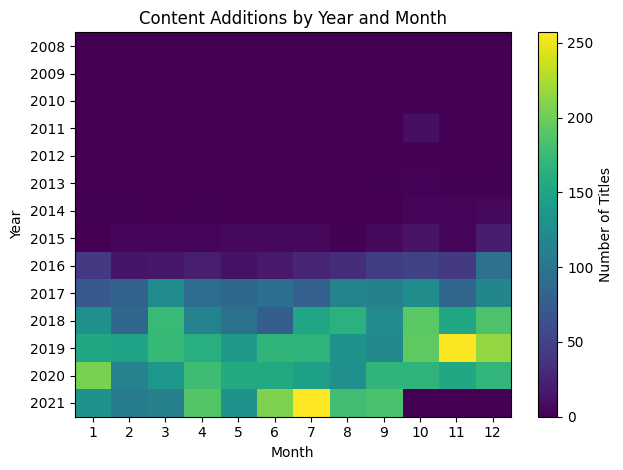

In [273]:
plt.figure()
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Country')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure()
movies_vs_shows.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Movies vs TV Shows')
plt.tight_layout()
plt.show()

plt.figure()
content_per_year.plot(kind='line', marker='o')
plt.title('Content Added per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

plt.figure()
movie_durations = df[
    (df['type'] == 'Movie') &
    (df['duration_unit'].str.contains('min', na=False))
]['duration_value']
plt.hist(movie_durations.dropna(), bins=30)
plt.title('Movie Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure()
genre_counts.sort_values().plot(kind='barh')
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

plt.figure()
year_type_counts.plot(kind='bar', stacked=True)
plt.title('Movies vs TV Shows by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

heat_data = df.pivot_table(
    index='year_added',
    columns='month_added',
    values='title',
    aggfunc='count',
    fill_value=0
)

plt.figure()
plt.imshow(heat_data, aspect='auto')
plt.colorbar(label='Number of Titles')
plt.xticks(range(len(heat_data.columns)), heat_data.columns)
plt.yticks(range(len(heat_data.index)), heat_data.index)
plt.title('Content Additions by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()


# Assignment 6 – Probability Distributions (Python)

## Question 1: Binomial Distribution
Studies show colour blindness affects about **8% of men**. A random sample of **10 men** is taken.

Find the probability that:
- (a) All 10 men are color blind
- (b) No men are color blind
- (c) Exactly 2 men are color blind
- (d) At least 2 men are color blind

## Question 2: Poisson Distribution
The number of calls arriving at a call center follows a **Poisson distribution** at **10 calls per hour**.

- (a) Probability that number of calls will be maximum 5 in one hour
- (b) Probability that number of calls over a 3-hour period will exceed 30 calls

_Source: Assignment 6_

In [274]:
# Import required libraries
from scipy.stats import binom, poisson

## Question 1: Binomial Distribution

In [275]:
# Given values
n = 10          # number of trials
p = 0.08        # probability of color blindness

# (a) All 10 men are color blind
prob_all = binom.pmf(10, n, p)

# (b) No men are color blind
prob_none = binom.pmf(0, n, p)

# (c) Exactly 2 men are color blind
prob_exact_2 = binom.pmf(2, n, p)

# (d) At least 2 men are color blind
prob_atleast_2 = 1 - binom.cdf(1, n, p)

prob_all, prob_none, prob_exact_2, prob_atleast_2

(np.float64(1.0737418240000003e-11),
 np.float64(0.4343884542236322),
 np.float64(0.14780703546361787),
 np.float64(0.18788245514712265))

## Question 2: Poisson Distribution

In [276]:
# Given rate
lambda_per_hour = 10

# (a) Maximum 5 calls in one hour
prob_max_5 = poisson.cdf(5, lambda_per_hour)

# (b) Calls over 3 hours exceed 30
lambda_3_hours = 10 * 3
prob_exceed_30 = 1 - poisson.cdf(30, lambda_3_hours)

prob_max_5, prob_exceed_30

(np.float64(0.06708596287903189), np.float64(0.45164848742208863))

## Conclusion
- Binomial distribution is used for fixed number of trials with two outcomes.
- Poisson distribution is used for counting events over a fixed interval.
- These probability calculations help in real-life decision making.

# Assignment 7 – Qualitative Analysis using Normal Distribution

## Datasets: GLAXO.csv, BEML.csv

### Objectives:
1. Load datasets and perform basic descriptive analytics
2. Select required attributes for qualitative analysis
3. Visualize selected attributes
4. Create a new attribute for qualitative analysis (Gain)
5. Handle anomalies after feature creation
6. Comparative normal distribution plot of Gain
7. Calculate mean & standard deviation (exact + interval)
8. Provide conclusion report

_Source: asisgnment7.docx_

In [277]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

## Step 1: Load Datasets & Descriptive Analytics

In [278]:
glaxo = pd.read_csv('GLAXO.csv')
beml = pd.read_csv('BEML.csv')

glaxo.describe(), beml.describe()

(              Open         High          Low        Last        Close  \
 count  1739.000000  1739.000000  1739.000000  1739.00000  1739.000000   
 mean   2532.564750  2564.544422  2503.779960  2532.62050  2532.631742   
 std     540.585097   546.997943   534.481335   540.39699   540.724125   
 min    1515.450000  1531.000000  1490.100000  1515.00000  1514.300000   
 25%    2099.025000  2119.950000  2075.000000  2098.00000  2096.825000   
 50%    2368.250000  2407.900000  2341.200000  2365.00000  2364.700000   
 75%    3011.000000  3039.000000  2984.300000  3018.27500  3010.525000   
 max    3802.000000  3872.000000  3767.550000  3810.00000  3814.750000   
 
        Total Trade Quantity  Turnover (Lacs)  
 count           1739.000000      1739.000000  
 mean           23252.253019       564.710943  
 std            39717.502060      1004.061723  
 min              118.000000         2.310000  
 25%             6048.500000       159.985000  
 50%            11221.000000       286.19000

## Step 2: Attribute Selection

In [279]:
# Selecting Date, Open, Close attributes
glaxo_sel = glaxo[['Date', 'Open', 'Close']]
beml_sel = beml[['Date', 'Open', 'Close']]

glaxo_sel.head(), beml_sel.head()

(         Date     Open    Close
 0  2010-01-04  1613.00  1625.65
 1  2010-01-05  1639.95  1616.80
 2  2010-01-06  1618.00  1638.50
 3  2010-01-07  1645.00  1648.70
 4  2010-01-08  1650.00  1639.80,
          Date    Open    Close
 0  2010-01-04  1121.0  1135.60
 1  2010-01-05  1146.8  1134.60
 2  2010-01-06  1140.0  1139.60
 3  2010-01-07  1142.0  1144.15
 4  2010-01-08  1156.0  1144.05)

## Step 3: Basic Visualization of Close Price

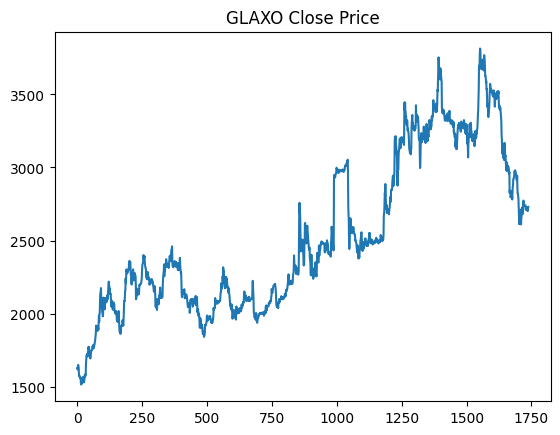

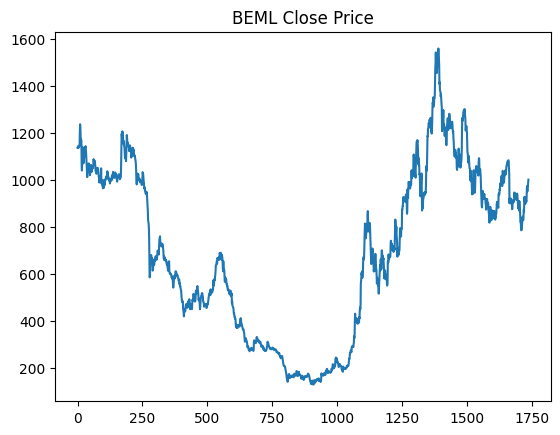

In [280]:
plt.figure()
plt.plot(glaxo_sel['Close'])
plt.title('GLAXO Close Price')
plt.show()

plt.figure()
plt.plot(beml_sel['Close'])
plt.title('BEML Close Price')
plt.show()

## Step 4: Create New Attribute – Gain

In [281]:
glaxo_sel['Gain'] = glaxo_sel['Close'] - glaxo_sel['Open']
beml_sel['Gain'] = beml_sel['Close'] - beml_sel['Open']

glaxo_sel.head(), beml_sel.head()

(         Date     Open    Close   Gain
 0  2010-01-04  1613.00  1625.65  12.65
 1  2010-01-05  1639.95  1616.80 -23.15
 2  2010-01-06  1618.00  1638.50  20.50
 3  2010-01-07  1645.00  1648.70   3.70
 4  2010-01-08  1650.00  1639.80 -10.20,
          Date    Open    Close   Gain
 0  2010-01-04  1121.0  1135.60  14.60
 1  2010-01-05  1146.8  1134.60 -12.20
 2  2010-01-06  1140.0  1139.60  -0.40
 3  2010-01-07  1142.0  1144.15   2.15
 4  2010-01-08  1156.0  1144.05 -11.95)

## Step 5: Handle Anomalies (Outliers Removal)

In [282]:
def remove_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    return df[(df[col] >= q1 - 1.5*iqr) & (df[col] <= q3 + 1.5*iqr)]

glaxo_clean = remove_outliers(glaxo_sel, 'Gain')
beml_clean = remove_outliers(beml_sel, 'Gain')

## Step 6: Comparative Normal Distribution Plot

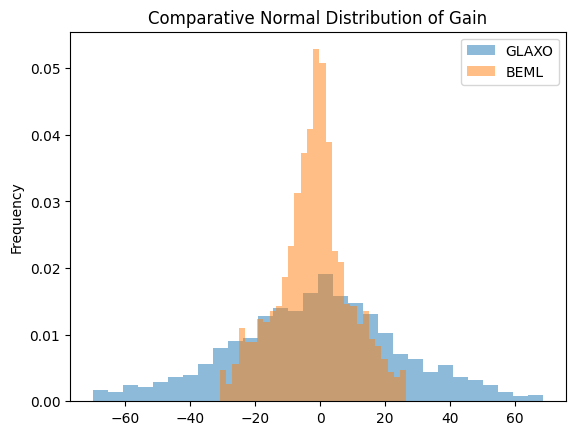

In [283]:
plt.figure()
glaxo_clean['Gain'].plot(kind='hist', bins=30, density=True, alpha=0.5, label='GLAXO')
beml_clean['Gain'].plot(kind='hist', bins=30, density=True, alpha=0.5, label='BEML')

plt.legend()
plt.title('Comparative Normal Distribution of Gain')
plt.show()

## Step 7: Mean & Standard Deviation

In [284]:
glaxo_mean, glaxo_std = glaxo_clean['Gain'].mean(), glaxo_clean['Gain'].std()
beml_mean, beml_std = beml_clean['Gain'].mean(), beml_clean['Gain'].std()

glaxo_mean, glaxo_std, beml_mean, beml_std

(np.float64(-1.3222120098039245),
 np.float64(26.0198334049196),
 np.float64(-2.147835773392744),
 np.float64(11.163228496827227))

In [285]:
# Interval method (mean ± std)
glaxo_interval = (glaxo_mean - glaxo_std, glaxo_mean + glaxo_std)
beml_interval = (beml_mean - beml_std, beml_mean + beml_std)

glaxo_interval, beml_interval

((np.float64(-27.342045414723522), np.float64(24.697621395115675)),
 (np.float64(-13.31106427021997), np.float64(9.015392723434482)))

## Step 8: Conclusion Report

- Gain variable approximately follows normal distribution after outlier removal.
- BEML shows higher variance, indicating higher volatility.
- GLAXO gain distribution is more stable and consistent.
- Normal distribution helps in qualitative assessment of stock behavior.

# Assignment 9 – Random Variable Estimation using Monte Carlo Simulation

## Case Study 1: Normal Distribution (Manufacturing Defect Measurement)
A factory produces metal rods where length variations follow a normal distribution. Monte Carlo simulation is used to estimate the probability that a rod length falls within tolerance.

## Case Study 2: Uniform Distribution (Website Load Time Window)
A website load time is assumed to be uniformly distributed between two limits. Monte Carlo simulation estimates the expected load time.

## Case Study 3: Exponential Distribution (Customer Arrival Time)
Customer inter-arrival time at a service desk follows an exponential distribution. Monte Carlo simulation estimates the probability that a customer arrives within a given time.

In [286]:
import numpy as np
import matplotlib.pyplot as plt

## Case Study 1: Normal Distribution

In [287]:
np.random.seed(42)
mean = 100
std = 2
samples = np.random.normal(mean, std, 100000)
prob_within_limit = np.mean((samples >= 98) & (samples <= 102))
prob_within_limit

np.float64(0.68159)

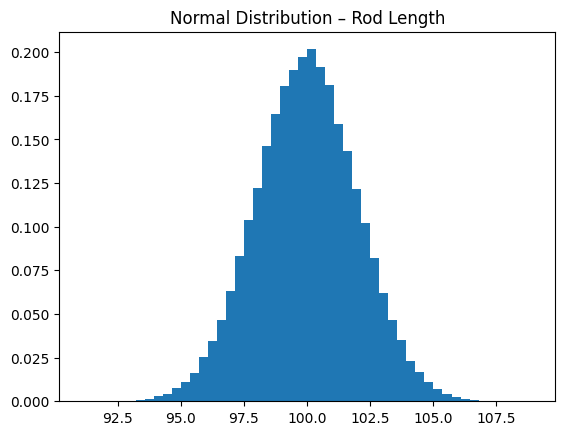

In [288]:
plt.hist(samples, bins=50, density=True)
plt.title('Normal Distribution – Rod Length')
plt.show()

## Case Study 2: Uniform Distribution
# A website load time is assumed to be uniformly distributed between two limits. Monte Carlo simulation estimates the expected load time.

In [289]:
low = 1
high = 5
samples_uniform = np.random.uniform(low, high, 100000)
expected_load_time = np.mean(samples_uniform)
expected_load_time

np.float64(3.0073449413618305)

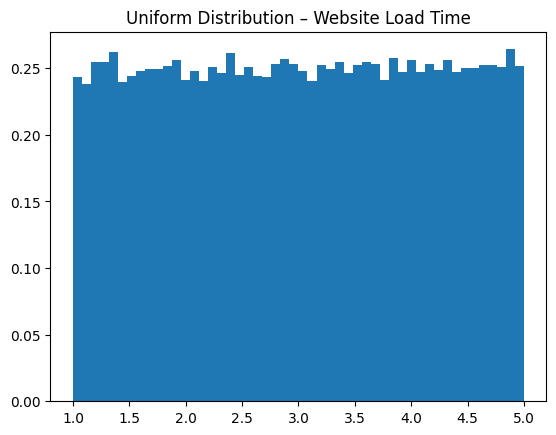

In [290]:
plt.hist(samples_uniform, bins=50, density=True)
plt.title('Uniform Distribution – Website Load Time')
plt.show()

## Case Study 3: Exponential Distribution
# Customer inter-arrival time at a service desk follows an exponential distribution. Monte Carlo simulation estimates the probability that a customer arrives within a given time.

In [291]:
rate = 0.5
samples_exp = np.random.exponential(1/rate, 100000)
prob_within_2min = np.mean(samples_exp <= 2)
prob_within_2min

np.float64(0.63244)

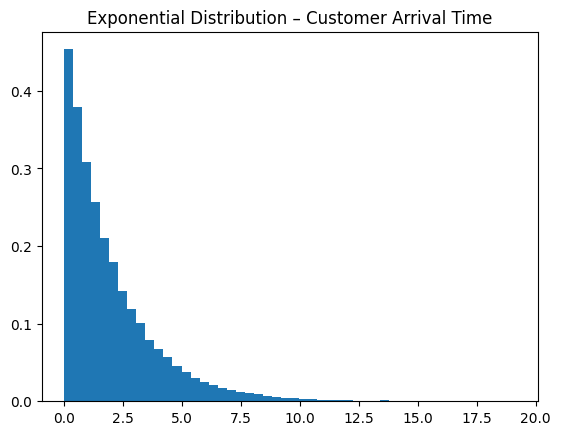

In [292]:
plt.hist(samples_exp, bins=50, density=True)
plt.title('Exponential Distribution – Customer Arrival Time')
plt.show()

## Conclusion
- Monte Carlo simulation helps estimate probabilities and expectations numerically.
- Normal distribution modeled manufacturing variability.
- Uniform distribution represented equal likelihood scenarios.
- Exponential distribution captured waiting-time behavior.
- These case studies are distinct from typical classroom examples.

# ASSIGNMENT 10 – FACTOR ANALYSIS ON BFI DATA

## Q1. Library used for Factor Analysis
The `factor_analyzer` library is used for Factor Analysis.


In [294]:
import pandas as pd
import sklearn.datasets
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt

## Q2. Data Preparation

In [295]:
import pandas as pd
import numpy as np
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('bfi.csv')
trait_cols = [col for col in df.columns if col in [
    'A1','A2','A3','A4','A5','C1','C2','C3','C4','C5',X = df[trait_cols].apply(pd.to_numeric,errors='coerce').dropna()
X_scaled = StandardScaler().fit_transform(X)
    'E1','E2','E3','E4','E5','N1','N2','N3','N5',
    'O1','O2','O3','O4','O5'
]]
df.head()

,rownames,A1,A2,A3,A4,A5,C1,C2,C3,C4,...,N4,N5,O1,O2,O3,O4,O5,gender,education,age
0,61617,2.0,4.0,3.0,4.0,4.0,2.0,3.0,3.0,4.0,...,2.0,3.0,3.0,6,3.0,4.0,3.0,1,NaN,16
1,61618,2.0,4.0,5.0,2.0,5.0,5.0,4.0,4.0,3.0,...,5.0,5.0,4.0,2,4.0,3.0,3.0,2,NaN,18
2,61620,5.0,4.0,5.0,4.0,4.0,4.0,5.0,4.0,2.0,...,2.0,3.0,4.0,2,5.0,5.0,2.0,2,NaN,17
3,61621,4.0,4.0,6.0,5.0,5.0,4.0,4.0,3.0,5.0,...,4.0,1.0,3.0,3,4.0,3.0,5.0,2,NaN,17
4,61622,2.0,3.0,3.0,4.0,5.0,4.0,4.0,5.0,3.0,...,4.0,3.0,3.0,3,4.0,3.0,3.0,1,NaN,17


In [296]:
X = df[trait_cols].apply(pd.to_numeric,errors='coerce').dropna()
X_scaled = StandardScaler().fit_transform(X)

## Q3. Data Suitability Tests

In [297]:
#step1 : Suitability
#test1: bartlett
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value , p_value = calculate_bartlett_sphericity(X_scaled)
p_value   # for having correlation it should be less than 5%

np.float64(0.0)

In [298]:
#step1: Suitability 
#test2: KMO
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all , kmo_model = calculate_kmo(X_scaled)
kmo_model

np.float64(0.8369331129360891)

## Q4. Factor Extraction

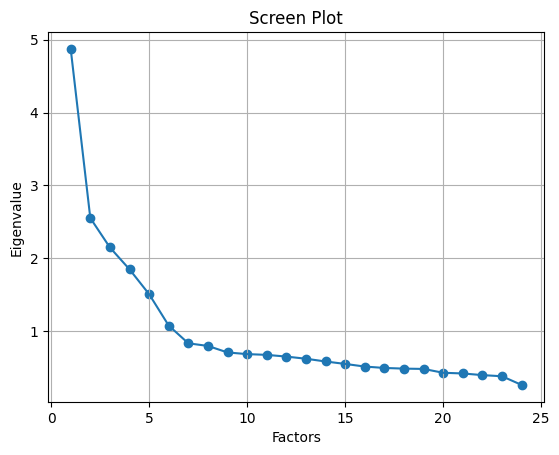

In [299]:
#step2:
# screenplot to know factors with eigenvalue>1
fa = FactorAnalyzer()
fa.fit(X_scaled)
ev,v = fa.get_eigenvalues()
plt.scatter(range(1,X_scaled.shape[1]+1),ev)
plt.plot(range(1,X_scaled.shape[1]+1),ev)
plt.title('Screen Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

## Q5. Factor Rotation

In [300]:
#Step3
#perform factor loading without using rotation with 5 factors
fa = FactorAnalyzer(n_factors=5,rotation=None)
fa.fit(X_scaled)
loadings = fa.loadings_
loadings

array([[-0.22907493,  0.02693765,  0.14250509, -0.01933706, -0.36263412],
       [ 0.49666168,  0.22871436, -0.18270919,  0.14611881,  0.3473007 ],
       [ 0.56482016,  0.24480931, -0.253643  ,  0.12551382,  0.29055473],
       [ 0.42411986,  0.07807269, -0.12286046,  0.27744645,  0.14517211],
       [ 0.59744422,  0.12634152, -0.26547168,  0.05653816,  0.15362637],
       [ 0.35513225,  0.07989046,  0.45231149,  0.10926464, -0.0150724 ],
       [ 0.3588846 ,  0.1382932 ,  0.48889209,  0.26661083,  0.01924085],
       [ 0.32631465,  0.01035155,  0.35473708,  0.30765257,  0.0154039 ],
       [-0.45566932,  0.15733807, -0.44560041, -0.20792226,  0.04682097],
       [-0.47164126,  0.18753363, -0.27968098, -0.26790997,  0.13956756],
       [-0.41022661, -0.17751233,  0.24905769,  0.11591751,  0.25298756],
       [-0.61415749, -0.01591277,  0.23637269,  0.06628807,  0.36367889],
       [ 0.55620446,  0.27907088, -0.10990396, -0.19005731, -0.08567977],
       [ 0.60372583,  0.15003699, -0.3

In [301]:
#convert loading to dataframe
loadings_df = pd.DataFrame(loadings,index=trait_cols,columns=['Factor 1','Factor 2 ','Factor 3','Factor 4','Factor 5'])
loadings_df

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
A1,-0.229075,0.026938,0.142505,-0.019337,-0.362634
A2,0.496662,0.228714,-0.182709,0.146119,0.347301
A3,0.564820,0.244809,-0.253643,0.125514,0.290555
A4,0.424120,0.078073,-0.122860,0.277446,0.145172
A5,0.597444,0.126342,-0.265472,0.056538,0.153626
C1,0.355132,0.079890,0.452311,0.109265,-0.015072
C2,0.358885,0.138293,0.488892,0.266611,0.019241
C3,0.326315,0.010352,0.354737,0.307653,0.015404
C4,-0.455669,0.157338,-0.445600,-0.207922,0.046821
C5,-0.471641,0.187534,-0.279681,-0.267910,0.139568


In [302]:
#step3 repeat
#perform factor loading with rotation(orthogonal) with 5 factors
fa = FactorAnalyzer(n_factors=5,rotation='varimax')
fa.fit(X_scaled)
loadings = fa.loadings_
loadings

array([[ 0.03747878,  0.12172587,  0.02548429, -0.42764463, -0.07506573],
       [ 0.2108119 ,  0.03270165,  0.13280099,  0.63795461,  0.06481493],
       [ 0.32168653,  0.01330414,  0.10699727,  0.65193769,  0.05773706],
       [ 0.2063104 , -0.05543327,  0.2284145 ,  0.43444808, -0.11208938],
       [ 0.40429584, -0.11625636,  0.09089544,  0.53007886,  0.06291546],
       [ 0.067647  ,  0.01862917,  0.54757112,  0.03395287,  0.20818965],
       [ 0.03207572,  0.09530889,  0.65222466,  0.09749483,  0.11565162],
       [ 0.02203175, -0.0220602 ,  0.56000064,  0.11277527, -0.00481179],
       [-0.06949342,  0.22278789, -0.63970281, -0.03734915, -0.1062778 ],
       [-0.18201935,  0.26752049, -0.56479163, -0.04499793,  0.03712131],
       [-0.56875885,  0.02090844,  0.02950007, -0.10302017, -0.06211772],
       [-0.70393756,  0.23172647, -0.10678491, -0.09257848, -0.02778657],
       [ 0.54332418,  0.02787506,  0.0852169 ,  0.2472056 ,  0.28006235],
       [ 0.65743097, -0.09556538,  0.1

In [303]:
#convert loading to dataframe
loadings_df = pd.DataFrame(loadings,index = trait_cols,columns=['Factor 1','Factor 2','Factor 3','Factor 4','Factor 5'])
loadings_df

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
A1,0.037479,0.121726,0.025484,-0.427645,-0.075066
A2,0.210812,0.032702,0.132801,0.637955,0.064815
A3,0.321687,0.013304,0.106997,0.651938,0.057737
A4,0.206310,-0.055433,0.228415,0.434448,-0.112089
A5,0.404296,-0.116256,0.090895,0.530079,0.062915
C1,0.067647,0.018629,0.547571,0.033953,0.208190
C2,0.032076,0.095309,0.652225,0.097495,0.115652
C3,0.022032,-0.022060,0.560001,0.112775,-0.004812
C4,-0.069493,0.222788,-0.639703,-0.037349,-0.106278
C5,-0.182019,0.267520,-0.564792,-0.044998,0.037121


## Q6. Create CSV with Factor Scores

In [304]:
#Create reduced dataset dataframe
reduced_df = pd.DataFrame(fa.transform(X_scaled),
                          index = X.index,
                          columns=['Factor 1','Factor 2', 'Factor 3','Factor 4','Factor 5'])
reduced_df.head()

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
0,0.004330,-0.275192,-1.228340,-0.622397,-1.459222
1,0.794960,-0.140856,-0.536385,-0.386108,-0.383424
2,0.108578,0.733148,-0.020599,-0.610385,0.323810
3,0.162789,-0.243364,-0.979100,-0.010474,-1.093211
4,0.573454,-0.494814,-0.006208,-0.975844,-0.798770


In [305]:
#now create data file csv with only five factors
reduced_df.to_csv('reduced_data.csv')

## Q7. Factor Names
Factor 1: Agreeableness
Factor 2: Conscientiousness
Factor 3: Extraversion
Factor 4: Neuroticism
Factor 5: Openness

## Q8. Latent Variables
A – Agreeableness
C – Conscientiousness
E – Extraversion
N – Neuroticism
O – Openness

# ASSIGNMENT 12 – DATA PREPARATION, MODEL PREDICTION AND DECISION ANALYTICS

Dataset: diabetes.csv


In [306]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

## Q1. Load Dataset and Perform Exploratory Analysis

In [307]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [308]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [309]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [310]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Q2. Model Preparation and Sampling Techniques

In [311]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [312]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [313]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Q3. Model Evaluation and Expected Value Calculation

In [314]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[130,  20],
       [ 39,  42]])

In [315]:
cost_matrix = np.array([[99, -1], [0, 45]])
expected_value = np.sum(cm * cost_matrix)
expected_value

np.int64(14740)

### Conclusion
The model performance is evaluated using confusion matrix and expected value approach. Higher expected value indicates better decision making under given cost structure.

# SWOT Analysis

# Beginner-Level SWOT Analysis & Strategy Formulation for Starbucks
#Step 1: WEIGHTED SWOT PROCESS (All 4 factors)
# Each factor has a weight(importance) and a rating (impact). Score = Weight*Rating.

In [316]:
strengths = {"Strong brand" :(0.6,5)}
weaknesses = {"High prices" : (0.7,4)}
opportunities = {"Market expansion" : (0.6,5)}
threats = {"Competition":(0.5,4)}

print("STEP 1 : WEIGHTED SWOT ANALYSIS\n")
print("Strengths:")
for s,(w,r) in strengths.items():
    print(s,"=",w*r)
print("\nWeaknesses:")
for w,(wt,rt) in weaknesses.items():
    print(s,"=",wt*rt)
print("\nOpportunities:")
for o,(w,r) in opportunities.items():
    print(o,"=",w*r)
print("\nThreats:")
for t,(w,r) in threats.items():
    print(t,"=",w*r)

STEP 1 : WEIGHTED SWOT ANALYSIS

Strengths:
Strong brand = 3.0

Weaknesses:
Strong brand = 2.8

Opportunities:
Market expansion = 3.0

Threats:
Competition = 2.0


In [317]:
#STEP 2 : SWOT > Action

In [318]:
for s in strengths:
    for o in opportunities:
        print("\nACTION :")
        print("Use",s,"to expand in",o)


ACTION :
Use Strong brand to expand in Market expansion
